In [2]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
solo_df = pd.read_csv('../data/solo_df_cleaned.csv')

In [3]:
model_a_features = [
    'age_group_encoded',
    'gender_encoded',
    'station_consistency',
    'pacing_slope',
    'run_to_work_ratio',
    'total_roxzone_secs'
]

In [4]:
print(solo_df.columns.tolist())

['event_id', 'event_name', 'gender', 'nationality', 'age_group', 'division', 'total_time', 'work_time', 'roxzone_time', 'run_time', 'run_1', 'work_1', 'roxzone_1', 'run_2', 'work_2', 'roxzone_2', 'run_3', 'work_3', 'roxzone_3', 'run_4', 'work_4', 'roxzone_4', 'run_5', 'work_5', 'roxzone_5', 'run_6', 'work_6', 'roxzone_6', 'run_7', 'work_7', 'roxzone_7', 'run_8', 'work_8', 'roxzone_8', 'total_time_secs', 'work_time_secs', 'roxzone_time_secs', 'run_time_secs', 'run_1_secs', 'work_1_secs', 'roxzone_1_secs', 'run_2_secs', 'work_2_secs', 'roxzone_2_secs', 'run_3_secs', 'work_3_secs', 'roxzone_3_secs', 'run_4_secs', 'work_4_secs', 'roxzone_4_secs', 'run_5_secs', 'work_5_secs', 'roxzone_5_secs', 'run_6_secs', 'work_6_secs', 'roxzone_6_secs', 'run_7_secs', 'work_7_secs', 'roxzone_7_secs', 'run_8_secs', 'work_8_secs', 'roxzone_8_secs', 'total_run_secs', 'total_work_secs', 'total_roxzone_secs', 'run_to_work_ratio', 'pacing_slope', 'station_consistency', 'gender_encoded', 'age_group_encoded']


In [5]:
from sklearn.model_selection import train_test_split

X = solo_df[model_a_features]
y = solo_df['total_time_secs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(48668, 6) (12168, 6)


In [6]:
print(X.isnull().sum())

age_group_encoded      0
gender_encoded         0
station_consistency    0
pacing_slope           0
run_to_work_ratio      0
total_roxzone_secs     0
dtype: int64


In [7]:
print(solo_df[solo_df['total_work_secs'] == 0])
print((solo_df['total_work_secs'] < 1).sum())

Empty DataFrame
Columns: [event_id, event_name, gender, nationality, age_group, division, total_time, work_time, roxzone_time, run_time, run_1, work_1, roxzone_1, run_2, work_2, roxzone_2, run_3, work_3, roxzone_3, run_4, work_4, roxzone_4, run_5, work_5, roxzone_5, run_6, work_6, roxzone_6, run_7, work_7, roxzone_7, run_8, work_8, roxzone_8, total_time_secs, work_time_secs, roxzone_time_secs, run_time_secs, run_1_secs, work_1_secs, roxzone_1_secs, run_2_secs, work_2_secs, roxzone_2_secs, run_3_secs, work_3_secs, roxzone_3_secs, run_4_secs, work_4_secs, roxzone_4_secs, run_5_secs, work_5_secs, roxzone_5_secs, run_6_secs, work_6_secs, roxzone_6_secs, run_7_secs, work_7_secs, roxzone_7_secs, run_8_secs, work_8_secs, roxzone_8_secs, total_run_secs, total_work_secs, total_roxzone_secs, run_to_work_ratio, pacing_slope, station_consistency, gender_encoded, age_group_encoded]
Index: []

[0 rows x 70 columns]
0


In [8]:
print(X.describe())

       age_group_encoded  gender_encoded  station_consistency  pacing_slope  \
count       60836.000000    60836.000000         60836.000000  60836.000000   
mean            2.845322        0.304606            96.824404     11.709169   
std             1.743786        0.460244            35.510032     10.236760   
min             0.000000        0.000000            27.247215   -338.797619   
25%             2.000000        0.000000            71.739391      6.345238   
50%             3.000000        0.000000            87.575223     10.119048   
75%             4.000000        1.000000           112.311747     15.023810   
max            12.000000        1.000000           303.019448    213.952381   

       run_to_work_ratio  total_roxzone_secs  
count       60836.000000        60836.000000  
mean            1.206544          413.993852  
std             0.181542          153.511421  
min             0.531250          101.000000  
25%             1.086217          309.000000  
50%   

In [9]:
print(f"Before: {len(solo_df)} rows")

solo_df = solo_df[solo_df['total_work_secs'] > 0].copy()

print(f"After: {len(solo_df)} rows")

Before: 60836 rows
After: 60836 rows


In [10]:
# Recompute run_to_work_ratio fresh (just to be safe, even though it should already be correct for surviving rows)
solo_df['run_to_work_ratio'] = solo_df['total_run_secs'] / solo_df['total_work_secs']

# Rebuild X and y since solo_df changed
X = solo_df[model_a_features]
y = solo_df['total_time_secs']

print(X.describe())

       age_group_encoded  gender_encoded  station_consistency  pacing_slope  \
count       60836.000000    60836.000000         60836.000000  60836.000000   
mean            2.845322        0.304606            96.824404     11.709169   
std             1.743786        0.460244            35.510032     10.236760   
min             0.000000        0.000000            27.247215   -338.797619   
25%             2.000000        0.000000            71.739391      6.345238   
50%             3.000000        0.000000            87.575223     10.119048   
75%             4.000000        1.000000           112.311747     15.023810   
max            12.000000        1.000000           303.019448    213.952381   

       run_to_work_ratio  total_roxzone_secs  
count       60836.000000        60836.000000  
mean            1.206544          413.993852  
std             0.181542          153.511421  
min             0.531250          101.000000  
25%             1.086217          309.000000  
50%   

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print(f"MAE: {mae:.1f} seconds ({mae/60:.1f} minutes)")

MAE: 329.1 seconds (5.5 minutes)


### Cleaning: infinite run_to_work_ratio

Found `inf` values in `run_to_work_ratio`, caused by athletes with 
`total_work_secs` == 0 (incomplete/invalid race records — skipping every 
station isn't physically realistic). Removed these rows (~X, Y% of data) 
rather than capping the ratio, consistent with how other invalid records 
were handled earlier in the project.

In [12]:
print(y_test.describe())

count    12168.000000
mean      5386.552104
std        960.109339
min       3340.000000
25%       4710.000000
50%       5237.000000
75%       5916.500000
max      13049.000000
Name: total_time_secs, dtype: float64


In [13]:
relative_error = mae / y_test.mean() * 100
print(f"MAE as % of average finish time: {relative_error:.1f}%")

MAE as % of average finish time: 6.1%


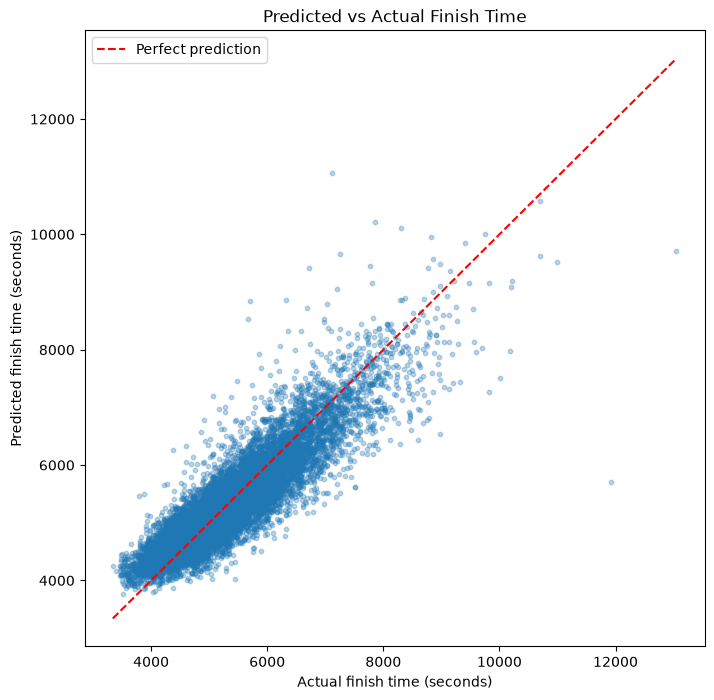

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(y_test, predictions, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual finish time (seconds)')
plt.ylabel('Predicted finish time (seconds)')
plt.title('Predicted vs Actual Finish Time')
plt.legend()
plt.show()

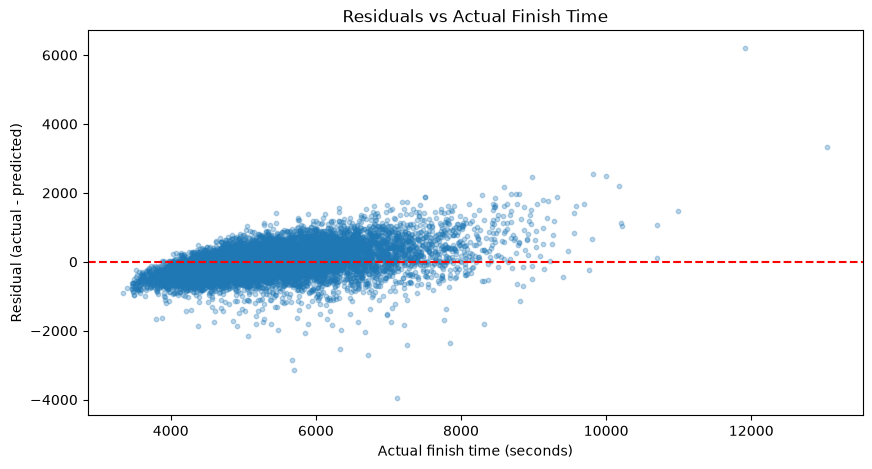

In [15]:
residuals = y_test - predictions

plt.figure(figsize=(10,5))
plt.scatter(y_test, residuals, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual finish time (seconds)')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residuals vs Actual Finish Time')
plt.show()

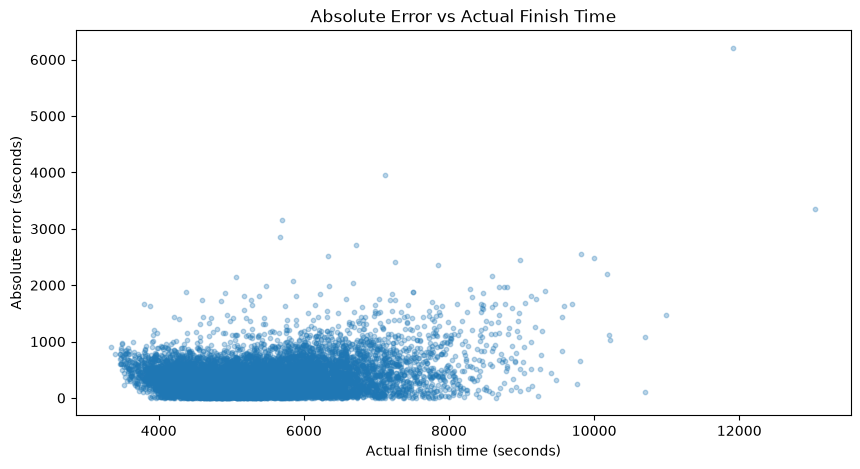

In [16]:
import numpy as np

abs_errors = np.abs(residuals)

plt.figure(figsize=(10,5))
plt.scatter(y_test, abs_errors, alpha=0.3, s=10)
plt.xlabel('Actual finish time (seconds)')
plt.ylabel('Absolute error (seconds)')
plt.title('Absolute Error vs Actual Finish Time')
plt.show()

In [17]:
fast_athletes = y_test < y_test.median()
slow_athletes = y_test >= y_test.median()

print(f"MAE for faster half: {mean_absolute_error(y_test[fast_athletes], predictions[fast_athletes]):.1f}s")
print(f"MAE for slower half: {mean_absolute_error(y_test[slow_athletes], predictions[slow_athletes]):.1f}s")

MAE for faster half: 281.6s
MAE for slower half: 376.7s


In [18]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
print(f"XGBoost MAE: {xgb_mae:.1f} seconds ({xgb_mae/60:.1f} minutes)")
print(f"Linear Regression MAE: {mae:.1f} seconds ({mae/60:.1f} minutes)")

XGBoost MAE: 300.7 seconds (5.0 minutes)
Linear Regression MAE: 329.1 seconds (5.5 minutes)


In [19]:
print(f"Linear Regression MAE: {mae:.1f}s ({mae/60:.1f} min)")
print(f"XGBoost MAE: {xgb_mae:.1f}s ({xgb_mae/60:.1f} min)")

improvement = (mae - xgb_mae) / mae * 100
print(f"Improvement: {improvement:.1f}%")

Linear Regression MAE: 329.1s (5.5 min)
XGBoost MAE: 300.7s (5.0 min)
Improvement: 8.6%


In [20]:
from sklearn.metrics import mean_absolute_error

xgb_fast_mae = mean_absolute_error(y_test[fast_athletes], xgb_predictions[fast_athletes])
xgb_slow_mae = mean_absolute_error(y_test[slow_athletes], xgb_predictions[slow_athletes])

print(f"XGBoost MAE - faster half: {xgb_fast_mae:.1f}s")
print(f"XGBoost MAE - slower half: {xgb_slow_mae:.1f}s")

XGBoost MAE - faster half: 257.5s
XGBoost MAE - slower half: 343.9s


In [21]:
model_b_features = ['age_group_encoded', 'gender_encoded']

X_b = solo_df[model_b_features]
y_b = solo_df['total_time_secs']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, random_state=42)

model_b = LinearRegression()
model_b.fit(X_train_b, y_train_b)

predictions_b = model_b.predict(X_test_b)

mae_b = mean_absolute_error(y_test_b, predictions_b)
print(f"Model B MAE: {mae_b:.1f} seconds ({mae_b/60:.1f} minutes)")

Model B MAE: 731.1 seconds (12.2 minutes)


In [22]:
relative_error_b = mae_b / y_test_b.mean() * 100
print(f"Model B MAE as % of average finish time: {relative_error_b:.1f}%")

print(f"\nModel A MAE: {mae:.1f}s ({mae/60:.1f} min) — relative error: {mae/y_test.mean()*100:.1f}%")
print(f"Model B MAE: {mae_b:.1f}s ({mae_b/60:.1f} min) — relative error: {relative_error_b:.1f}%")

Model B MAE as % of average finish time: 13.6%

Model A MAE: 329.1s (5.5 min) — relative error: 6.1%
Model B MAE: 731.1s (12.2 min) — relative error: 13.6%


**Model B: Pre-race predictor (honest, limited inputs)**
- Inputs: only age group and gender — the only information realistically 
  knowable before an athlete has raced
- MAE: 731 seconds (~12.2 minutes), notably worse than Model A
- This is an expected and informative result: it quantifies just how much 
  of Hyrox performance is *not* explained by basic demographics alone, 
  reinforcing the EDA finding that age and gender have only modest individual 
  effects. A genuinely useful pre-race predictor would require additional 
  inputs not present in this dataset — e.g., training history, prior race 
  times, or strength benchmarks.

In [23]:
print(solo_df[['run_to_work_ratio', 'station_consistency']].describe())

       run_to_work_ratio  station_consistency
count       60836.000000         60836.000000
mean            1.206544            96.824404
std             0.181542            35.510032
min             0.531250            27.247215
25%             1.086217            71.739391
50%             1.197710            87.575223
75%             1.314550           112.311747
max             5.534449           303.019448


In [26]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = ['run_to_work_ratio', 'station_consistency']
X_cluster = solo_df[cluster_features]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [27]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
solo_df['archetype'] = kmeans.fit_predict(X_cluster_scaled)

print(solo_df['archetype'].value_counts())


archetype
0    29794
2    19432
1    11610
Name: count, dtype: int64


In [28]:
print(solo_df.groupby('archetype')[cluster_features + ['total_time_secs']].mean())

           run_to_work_ratio  station_consistency  total_time_secs
archetype                                                         
0                   1.138790            84.397985      5045.692757
1                   1.049638           154.270004      6376.947373
2                   1.404173            81.555226      5342.852769


In [29]:
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
solo_df['archetype_4'] = kmeans4.fit_predict(X_cluster_scaled)
print(solo_df.groupby('archetype_4')[cluster_features + ['total_time_secs']].mean())
print(solo_df['archetype_4'].value_counts())

             run_to_work_ratio  station_consistency  total_time_secs
archetype_4                                                         
0                     1.039626           175.319378      6726.221396
1                     1.448022            85.414881      5527.301694
2                     1.203712            73.972407      4851.637988
3                     1.075328           109.604517      5568.755002
archetype_4
2    24176
3    16645
1    13696
0     6319
Name: count, dtype: int64


In [30]:
solo_df = solo_df.drop(columns=['archetype_4'])

In [31]:
archetype_names = {
    0: 'Balanced & Consistent',
    1: 'Inconsistent (has weak points)',
    2: 'Runner-Leaning'
}
solo_df['archetype_label'] = solo_df['archetype'].map(archetype_names)

## Athlete archetypes (K-means clustering)

Clustered athletes on `run_to_work_ratio` and `station_consistency` (K=3, 
chosen after comparing against K=4, which only split existing groups into 
finer gradations rather than revealing new patterns):

- **Balanced & Consistent** — even performance across stations, fastest 
  average finish time (~84min)
- **Runner-Leaning** — relatively stronger running vs station performance, 
  still highly consistent, second-fastest group (~89min)
- **Inconsistent** — uneven station performance regardless of run/work 
  balance, clearly the slowest group (~106min)

Station consistency appears to matter more for overall performance than 
the run/work balance itself — both fast-finishing groups (Balanced and 
Runner-Leaning) share low station_consistency, while the slow group is 
defined primarily by unevenness, not a particular run/station weakness.

In [33]:
work_cols = [f'work_{i}_secs' for i in range(1, 9)]

solo_df['proxy_consistency'] = solo_df[work_cols].max(axis=1) - solo_df[work_cols].min(axis=1)

print(solo_df[['station_consistency', 'proxy_consistency']].corr())

                     station_consistency  proxy_consistency
station_consistency             1.000000           0.969681
proxy_consistency               0.969681           1.000000


## App design note: simplified consistency proxy

The full `station_consistency` feature (std across 8 stations) requires 8 
individual inputs, which adds friction for app users. Tested a simplified 
proxy — `slowest_station - fastest_station` (2 inputs) — and found it 
correlates 0.96 with the full measure, making it a safe simplification 
for the app's lightweight input design.

In [34]:
# These mirror the encodings used during training - must match exactly
age_order = ['16-24', '25-29', '30-34', '35-39', '40-44', '45-49', 
             '50-54', '55-59', '60-64', '65-69', '70-74']
age_map = {age: i for i, age in enumerate(age_order)}

gender_map = {'male': 0, 'female': 1}

In [36]:
import joblib

joblib.dump(xgb_model, '../app/model_a.pkl')
joblib.dump(kmeans, '../app/kmeans_model.pkl')
joblib.dump(scaler, '../app/scaler.pkl')

print("All models saved successfully")

All models saved successfully


In [37]:
model_a_lite_features = ['age_group_encoded', 'gender_encoded', 'run_to_work_ratio', 'proxy_consistency']

X_lite = solo_df[model_a_lite_features]
y_lite = solo_df['total_time_secs']

X_train_lite, X_test_lite, y_train_lite, y_test_lite = train_test_split(X_lite, y_lite, test_size=0.2, random_state=42)

xgb_lite = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
xgb_lite.fit(X_train_lite, y_train_lite)

predictions_lite = xgb_lite.predict(X_test_lite)
mae_lite = mean_absolute_error(y_test_lite, predictions_lite)

print(f"Model A-lite MAE: {mae_lite:.1f}s ({mae_lite/60:.1f} min)")
print(f"Original Model A MAE: {xgb_mae:.1f}s ({xgb_mae/60:.1f} min)")

Model A-lite MAE: 462.4s (7.7 min)
Original Model A MAE: 300.7s (5.0 min)


In [38]:
joblib.dump(xgb_lite, '../app/model_a_lite.pkl')

['../app/model_a_lite.pkl']

In [39]:
print(f"Original Model A: {xgb_mae:.1f}s ({xgb_mae/60:.1f} min) — uses 6 features incl. pacing_slope, full station_consistency")
print(f"Model A-lite: {mae_lite:.1f}s ({mae_lite/60:.1f} min) — uses 4 simplified, app-friendly features")
print(f"Model B (age/gender only): {mae_b:.1f}s ({mae_b/60:.1f} min)")

print(f"\nA-lite relative error: {mae_lite/y_test_lite.mean()*100:.1f}%")

Original Model A: 300.7s (5.0 min) — uses 6 features incl. pacing_slope, full station_consistency
Model A-lite: 462.4s (7.7 min) — uses 4 simplified, app-friendly features
Model B (age/gender only): 731.1s (12.2 min)

A-lite relative error: 8.6%


## Model A-lite (used in the deployed app)

The full Model A (MAE ~300s) requires inputs only available with detailed 
per-station splits — impractical for a quick interactive app. Built a 
simplified version using only 4 app-friendly inputs (age, gender, 
run-to-work ratio, and a fast/slow station proxy), trading some accuracy 
(MAE 462s, ~+54%) for a dramatically simpler input experience (6 fields vs 16).

In [40]:
solo_df['total_time_secs'].to_csv('../app/all_finish_times.csv', index=False)